In [1]:
import numpy as np
import re
import pandas as pd

In [2]:
df=pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [3]:
# pd.set_option('display.max_columns',None)
# pd.set_option('display.max_rows',None)
# pd.set_option('display.max_colwidth',None)

In [4]:
df.head(1)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,smriti apartment,56,0.45,7500.0,600.0,Super Built up area 600(55.74 sq.m.),1,1,2,not available,3.0,NaN,10+ Year Old,"['Sector 54 chowk metro station', 'Sector metr...",[],"['Power Back-up', 'Feng Shui / Vaastu Complian..."


## 1. areaWithType

In [5]:
df[['area','areaWithType']].sample(5)

,area,areaWithType
1072,2940.0,Super Built up area 2940(273.13 sq.m.)
2480,2812.0,Super Built up area 2812(261.24 sq.m.)Built Up...
1771,1671.0,Super Built up area 1671(155.24 sq.m.)Built Up...
997,1526.0,Carpet area: 1526 (141.77 sq.m.)
3337,5400.0,Plot area 600(501.68 sq.m.)


In [6]:
# this function extracts super built up area
def get_super_built_up_area(text):
    match=re.search(r'Super Built up area (\d+\.?\d*)',text)
    if match:
        return float(match.group(1))
    return None

In [7]:
#this function extracts the built up area or carpet area 
def get_area(text, area_type):
    match=re.search(area_type+r'\s*:\s*(\d+\.?\d+)',text)
    if match:
        return float(match.group(1))
    return None

In [8]:
#this function chcks if the area is provided in sq.m. and converts it to sqrt if needed
def convert_to_sqft(text,area_value):
    if area_value is None:
        return None
    match=re.search(r'{}\((\d+\.?\d*) sq.m.\)'.format(area_value),text)
    if match:
        sq_m_value=float(match.group(1))
        return sq_m_value*10.7639
    return area_value

In [9]:
#extract super built up area and convert to sqft if needed
df['super_built_up_area']=df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['super_built_up_area']),axis=1)
#extract built up area and convert to sqft if needed
df['built_up_area']=df['areaWithType'].apply(lambda x:get_area(x,'Built Up area'))
df['built_up_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['built_up_area']),axis=1)
#extract carpet area and convert to sqft if needed
df['carpet_area']=df['areaWithType'].apply(lambda x:get_area(x,'Carpet area'))
df['carpet_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['carpet_area']),axis=1)


In [10]:
df.sample(5)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
3399,house,independent,7,6.50,15046.0,4320.0,Plot area 480(401.34 sq.m.),3,2,3+,not available,NaN,NaN,10+ Year Old,"['Geeta Nursing Home Gurgaon', 'Chiranjiv Hosp...",[],['Private Garden / Terrace'],NaN,NaN,NaN
649,house,independent,14,6.40,20317.0,3150.0,Plot area 350(292.64 sq.m.)Built Up area: 349 ...,6,6,3+,others,3.0,North,10+ Year Old,"['Sheetla Mata Mandir', 'Hsbc bank ATM', 'Hdfc...",NaN,"['Maintenance Staff', 'Water Storage', 'Park',...",NaN,349.0,348.0
2145,flat,ireo the grand arch,58,2.20,13480.0,1632.0,Super Built up area 1632(151.62 sq.m.)Built Up...,2,2,1,study room,5.0,North-East,1 to 5 Year Old,"['Sector 55-56 Rapid Metro', 'Paras Trinity Ma...","['6 Fan', '1 Exhaust Fan', '2 Geyser', '1 Stov...","['Power Back-up', 'Feng Shui / Vaastu Complian...",1632.0,1432.0,1232.0
3425,flat,shree vardhman victoria,70,1.63,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,3,3,"servant room,others",5.0,East,0 to 1 Year Old,"['Airia Mall', 'Golf Course Extn Road', 'Sohna...","['4 AC', '1 Modular Kitchen', 'No Bed', 'No Ch...","['Feng Shui / Vaastu Compliant', 'Security / F...",1950.0,NaN,1161.0
3005,house,dlf city plots phase 2,25,6.50,33592.0,1935.0,Plot area 215(179.77 sq.m.),9,9,3+,"pooja room,store room,study room,servant room",3.0,West,10+ Year Old,"['Vodafone belvedere towers metro station', 'D...","['9 Wardrobe', '24 Fan', '1 Exhaust Fan', '9 G...","['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,NaN,NaN


In [11]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
10,flat,the close north,50,2.92,11209.0,2605.0,Super Built up area 2605(242.01 sq.m.)Built Up...,3,3,3,servant room,10.0,North,5 to 10 Year Old,"['Sector 55-56 Metro Station', 'Eros City Squa...","['4 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Ge...","['Centrally Air Conditioned', 'Water purifier'...",2605.0,2600.00,2100.0
21,flat,experion windchants,112,2.80,11470.0,2441.0,Super Built up area 2441(226.78 sq.m.)Built Up...,2,3,2,"study room,servant room",9.0,South-East,1 to 5 Year Old,"['Ansal Plaza', 'Dwaraka Expressway', 'First S...","['4 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Centrally Air Conditioned', 'Water purifier'...",2441.0,1939.03,1800.0
24,flat,dlf regal gardens,90,1.78,8036.0,2215.0,Super Built up area 2215(205.78 sq.m.)Built Up...,4,4,3+,not available,8.0,South,1 to 5 Year Old,"['SS Omnia, Sector 86', 'Numberdar market, IMT...",NaN,"['Water purifier', 'Security / Fire Alarm', 'P...",2215.0,2000.00,1650.0
25,flat,dlf regal gardens,90,1.24,7065.0,1755.0,Super Built up area 1755(163.04 sq.m.)Built Up...,3,3,3+,others,9.0,South,1 to 5 Year Old,"['SS Omnia, Sector 86', 'Numberdar market, IMT...",NaN,"['Feng Shui / Vaastu Compliant', 'Security / F...",1755.0,1600.00,1400.0
26,flat,dlf the ultima,81,2.34,11185.0,2092.0,Super Built up area 2092(194.35 sq.m.)Built Up...,3,4,3+,servant room,14.0,South-East,1 to 5 Year Old,"['Huda Metro Station (Gurugram)', 'Vatika Town...","['7 Fan', '1 Fridge', '1 Exhaust Fan', '4 Geys...","['Centrally Air Conditioned', 'Water purifier'...",2092.0,1760.00,1670.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3913,flat,la vida by tata housing,113,2.35,10599.0,2217.0,Super Built up area 2217(205.97 sq.m.)Built Up...,3,3,3,servant room,11.0,North-East,0 to 1 Year Old,"['Dwarka Sector 21', 'Pacific D21 Mall', 'Bajg...","['1 Geyser', 'No AC', 'No Bed', 'No Chimney', ...","['Centrally Air Conditioned', 'Water purifier'...",2217.0,2210.00,1720.0
3921,flat,ss the leaf,85,1.93,8075.0,2390.0,Super Built up area 2408(223.71 sq.m.)Built Up...,3,4,3,servant room,7.0,North-East,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...","['3 Wardrobe', '4 Fan', '10 Light', 'No AC', '...","['Centrally Air Conditioned', 'Water purifier'...",2408.0,2400.00,2390.0
3923,flat,ild greens,37,1.05,7500.0,1400.0,Super Built up area 1875(174.19 sq.m.)Built Up...,3,3,3,not available,4.0,NaN,0 to 1 Year Old,"['The Esplanade Mall', 'Gurgaon Road', 'Delhi ...","['1 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Ge...","['Feng Shui / Vaastu Compliant', 'Lift(s)']",1875.0,1500.00,1400.0
3927,flat,siddhartha apartment,95,0.72,3664.0,1965.0,Super Built up area 1965(182.55 sq.m.)Built Up...,3,3,2,others,4.0,East,1 to 5 Year Old,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...","['1 Wardrobe', '1 Modular Kitchen', 'No AC', '...","['Lift(s)', 'Park', 'Maintenance Staff', 'Visi...",1965.0,1800.00,1600.0


In [12]:
df[df['areaWithType'].str.contains('Plot')].shape

(760, 20)

In [13]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_crore           20
price_per_sqft           20
area                     20
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 21
facing                 1170
agePossession             1
nearbyLocations         201
furnishDetails         1029
features                703
super_built_up_area    2018
built_up_area          2719
carpet_area            1949
dtype: int64

In [14]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price_in_crore','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [15]:
all_nan_df.shape

(608, 7)

In [16]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price_in_crore','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [17]:
all_nan_df.head(100)

,price_in_crore,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,6.25,house,5400.0,Plot area 600(501.68 sq.m.),NaN,NaN,NaN
6,0.70,house,720.0,Plot area 80(66.89 sq.m.),NaN,NaN,NaN
8,11.75,house,5056.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
16,2.40,house,2000.0,Plot area 2000(185.81 sq.m.),NaN,NaN,NaN
17,2.30,house,1352.0,Plot area 160(133.78 sq.m.),NaN,NaN,NaN
...,...,...,...,...,...,...,...
644,4.50,house,4950.0,Plot area 550(459.87 sq.m.),NaN,NaN,NaN
646,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,NaN,NaN
655,12.25,house,5850.0,Plot area 5850(543.48 sq.m.),NaN,NaN,NaN
656,4.00,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN


In [18]:
#function to extract plot area from areawithtype column
def extract_plot_area(area_with_type):
    match=re.search(r'Plot area (\d+\.?\d*)',area_with_type)
    return float(match.group(1)) if match else None

In [19]:
all_nan_df['built_up_area']=all_nan_df['areaWithType'].apply(extract_plot_area)

In [20]:
all_nan_df.head(5)

,price_in_crore,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,6.25,house,5400.0,Plot area 600(501.68 sq.m.),NaN,600.0,NaN
6,0.70,house,720.0,Plot area 80(66.89 sq.m.),NaN,80.0,NaN
8,11.75,house,5056.0,Plot area 502(419.74 sq.m.),NaN,502.0,NaN
16,2.40,house,2000.0,Plot area 2000(185.81 sq.m.),NaN,2000.0,NaN
17,2.30,house,1352.0,Plot area 160(133.78 sq.m.),NaN,160.0,NaN


In [21]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area'])==9.0:
            return row['built_up_area']*9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area']*10.7
        else:
            return row['built_up_area']

In [22]:
all_nan_df['built_up_area']=all_nan_df.apply(convert_scale,axis=1)

In [23]:
#update the original dataframe
df.update(all_nan_df)

In [24]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_crore           20
price_per_sqft           20
area                     20
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 21
facing                 1170
agePossession             1
nearbyLocations         201
furnishDetails         1029
features                703
super_built_up_area    2018
built_up_area          2111
carpet_area            1949
dtype: int64

## 2.Additional Romm

In [25]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1686
servant room                                      709
study room                                        251
others                                            235
pooja room                                        170
                                                 ... 
servant room,study room,store room,pooja room       1
servant room,pooja room,store room,study room       1
store room,servant room,study room,pooja room       1
study room,others,servant room                      1
others,study room                                   1
Name: count, Length: 66, dtype: int64

In [26]:
#additional room
#list of new columns
new_cols=['study room','servant room','store room','pooja ghar','others']
#populate the new columns based on the 'additional room'
for col in new_cols:
    df[col]=df['additionalRoom'].str.contains(col).astype(int)

In [27]:
df.head(5)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others
0,flat,smriti apartment,56,0.45,7500.0,600.0,Super Built up area 600(55.74 sq.m.),1,1,2,...,[],"['Power Back-up', 'Feng Shui / Vaastu Complian...",600.0,NaN,NaN,0,0,0,0,0
1,flat,signature global park,48,0.54,7200.0,750.0,Carpet area: 750 (69.68 sq.m.),2,2,2,...,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",NaN,NaN,750.0,0,0,0,0,0
2,flat,ats triumph,104,1.85,8078.0,2290.0,Super Built up area 2290(212.75 sq.m.),3,4,3+,...,"['7 Fan', '7 Light', '1 Modular Kitchen', 'No ...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...",2290.0,NaN,NaN,1,1,1,0,0
3,flat,pareena laxmi apartments,99,0.32,6106.0,524.0,Super Built up area 524(48.68 sq.m.)Carpet are...,2,2,2,...,[],"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'S...",524.0,NaN,424.8,0,0,0,0,0
4,flat,m3m woodshire,107,1.40,5929.0,2361.0,Super Built up area 2361(219.34 sq.m.),3,4,0,...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Power Back-up', 'Intercom Facility', 'Lift(s...",2361.0,NaN,NaN,0,0,0,0,0


## 3.age possession

In [28]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1703
5 to 10 Year Old       607
0 to 1 Year Old        550
undefined              356
10+ Year Old           351
Under Construction      92
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Aug 2023                 7
Jun 2024                 7
Dec 2025                 7
Nov 2023                 5
Aug 2024                 5
Jul 2024                 4
Oct 2023                 4
Jan 2025                 4
By 2025                  4
Sep 2023                 4
Nov 2024                 3
May 2024                 3
Feb 2024                 3
By 2027                  2
Aug 2025                 2
Jun 2027                 2
Dec 2026                 2
Jul 2027                 2
Oct 2025                 2
Jul 2025                 2
Sep 2025                 2
Apr 2026      

In [29]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [30]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [31]:
df['agePossession'].value_counts()

agePossession
Relatively New        1703
New Property           646
Moderately Old         607
Undefined              357
Old Property           351
Under Construction     287
Name: count, dtype: int64

In [33]:
df['agePossession'].sample(5)

2265             Undefined
2249    Under Construction
3113        Relatively New
3914        Moderately Old
1212          New Property
Name: agePossession, dtype: object

In [34]:
df.head()

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others
0,flat,smriti apartment,56,0.45,7500.0,600.0,Super Built up area 600(55.74 sq.m.),1,1,2,...,[],"['Power Back-up', 'Feng Shui / Vaastu Complian...",600.0,NaN,NaN,0,0,0,0,0
1,flat,signature global park,48,0.54,7200.0,750.0,Carpet area: 750 (69.68 sq.m.),2,2,2,...,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",NaN,NaN,750.0,0,0,0,0,0
2,flat,ats triumph,104,1.85,8078.0,2290.0,Super Built up area 2290(212.75 sq.m.),3,4,3+,...,"['7 Fan', '7 Light', '1 Modular Kitchen', 'No ...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...",2290.0,NaN,NaN,1,1,1,0,0
3,flat,pareena laxmi apartments,99,0.32,6106.0,524.0,Super Built up area 524(48.68 sq.m.)Carpet are...,2,2,2,...,[],"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'S...",524.0,NaN,424.8,0,0,0,0,0
4,flat,m3m woodshire,107,1.40,5929.0,2361.0,Super Built up area 2361(219.34 sq.m.),3,4,0,...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Power Back-up', 'Intercom Facility', 'Lift(s...",2361.0,NaN,NaN,0,0,0,0,0


## 4.furnish details


In [35]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1872,NaN,NaN
818,[],"['Security / Fire Alarm', 'Power Back-up', 'Fe..."
205,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN
98,NaN,"['Security / Fire Alarm', 'Power Back-up', 'Fe..."
2387,NaN,"['Feng Shui / Vaastu Compliant', 'Security / F..."


In [36]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


In [37]:
furnishings_df.shape

(3951, 19)

In [38]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\palas\AppData\Local\Temp\ipykernel_14332\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [39]:
furnishings_df.sample(5)

,AC,Fridge,Exhaust Fan,Wardrobe,Modular Kitchen,Bed,Geyser,Water Purifier,Microwave,Light,Fan,Curtains,TV,Chimney,Stove,Dining Table,Sofa,Washing Machine
1036,4,0,1,4,0,0,3,0,1,10,6,1,0,1,0,0,0,0
2421,6,1,1,4,1,0,6,0,1,15,7,1,0,1,1,0,0,1
1494,5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
690,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1534,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [40]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [42]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

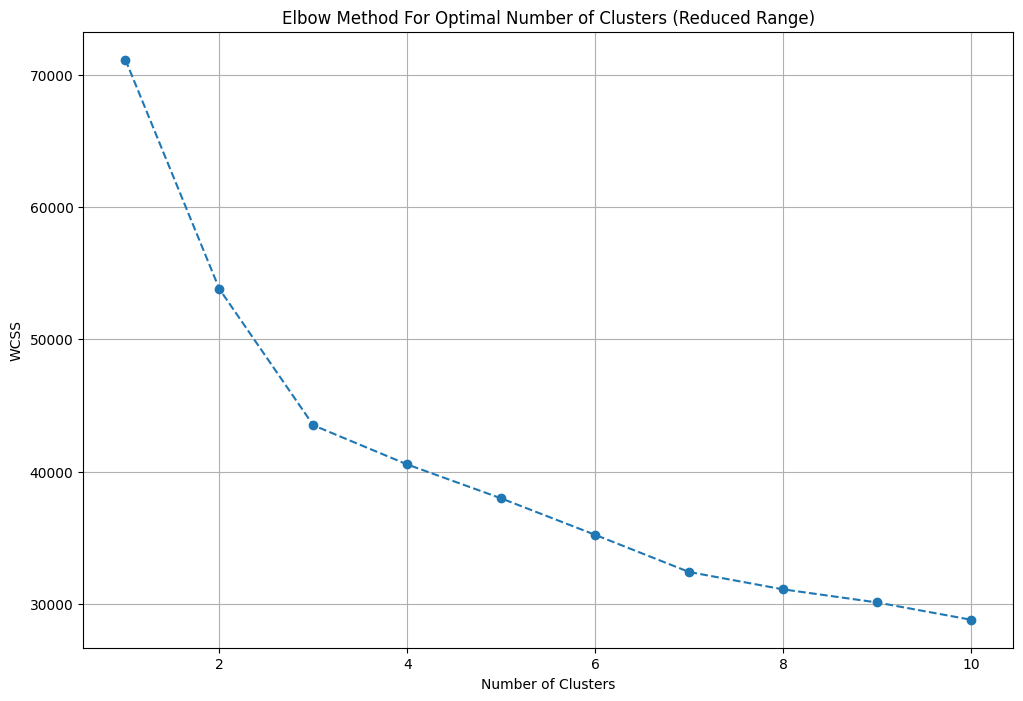

In [43]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [44]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [45]:
df = df.iloc[:,:-18]

In [46]:
df['furnishing_type'] = cluster_assignments

In [47]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
1632,"['1 Fan', '1 Geyser', '1 Chimney', '1 Modular ...",1
1188,"['6 Fan', '6 Light', 'No AC', 'No Bed', 'No Ch...",1
3612,NaN,1
3396,"['3 Wardrobe', '3 Fan', '1 Modular Kitchen', '...",1
2220,[],1


## 5.features

In [48]:
df[['society','features']].sample(5)

,society,features
602,sai kripa floors 5,NaN
2184,independent,"['Feng Shui / Vaastu Compliant', 'Private Gard..."
1762,mapsko mount ville,"['Centrally Air Conditioned', 'Water purifier'..."
1573,indiabulls centrum park,NaN
3035,central park resorts,"['Intercom Facility', 'Lift(s)', 'High Ceiling..."


In [49]:
df['features'].isnull().sum()

np.int64(703)

In [51]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."


In [52]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [53]:
temp_df = df[df['features'].isnull()]

In [54]:
temp_df.shape

(703, 26)

In [55]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [56]:
df.loc[temp_df.index,'features'] = x.values

In [57]:
df['features'].isnull().sum()

np.int64(546)

In [58]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [59]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [60]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,...,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
3799,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1240,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0
3331,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,1,1,0,0,0
736,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,1,1,0,0
772,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [61]:
features_binary_df.shape

(3951, 130)

In [62]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

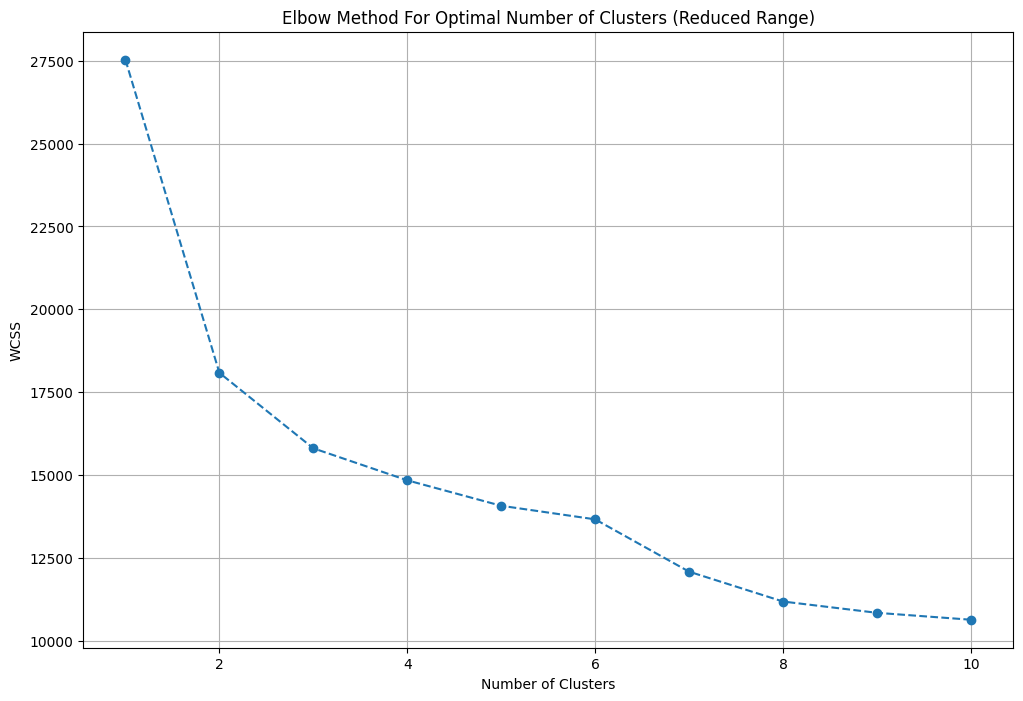

In [63]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [64]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [65]:
df['luxury_score'] = luxury_score

In [66]:
df.head()

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,features_list,luxury_score
0,flat,smriti apartment,56,0.45,7500.0,600.0,Super Built up area 600(55.74 sq.m.),1,1,2,...,NaN,NaN,0,0,0,0,0,1,"[Power Back-up, Feng Shui / Vaastu Compliant, ...",57
1,flat,signature global park,48,0.54,7200.0,750.0,Carpet area: 750 (69.68 sq.m.),2,2,2,...,NaN,750.0,0,0,0,0,0,1,"[Security / Fire Alarm, Feng Shui / Vaastu Com...",111
2,flat,ats triumph,104,1.85,8078.0,2290.0,Super Built up area 2290(212.75 sq.m.),3,4,3+,...,NaN,NaN,1,1,1,0,0,1,"[Security / Fire Alarm, Feng Shui / Vaastu Com...",117
3,flat,pareena laxmi apartments,99,0.32,6106.0,524.0,Super Built up area 524(48.68 sq.m.)Carpet are...,2,2,2,...,NaN,424.8,0,0,0,0,0,1,"[Feng Shui / Vaastu Compliant, Lift(s), Swimmi...",50
4,flat,m3m woodshire,107,1.40,5929.0,2361.0,Super Built up area 2361(219.34 sq.m.),3,4,0,...,NaN,NaN,0,0,0,0,0,1,"[Power Back-up, Intercom Facility, Lift(s), Sw...",67


In [67]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [68]:
df.sample(5)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
3677,flat,bptp freedom park life,57,5.50,8982.0,6123.0,Built Up area: 5010 (465.44 sq.m.),5,6,3+,...,NaN,5010.0,NaN,0,1,0,0,0,0,153
535,flat,dlf the ultima,81,2.29,10928.0,2096.0,Super Built up area 2100(195.1 sq.m.),3,4,3+,...,2100.0,NaN,NaN,0,1,0,0,0,2,103
1292,house,vipul tatvam villa,48,8.40,21000.0,4000.0,Plot area 4000(371.61 sq.m.),4,5,3+,...,NaN,4000.0,NaN,1,1,0,0,0,0,49
1748,flat,emaar mgf palm hills,77,1.64,8410.0,1950.0,Super Built up area 1950(181.16 sq.m.),4,3,3,...,1950.0,NaN,NaN,0,1,0,0,0,1,102
589,house,independent,9,0.60,10753.0,558.0,Plot area 62(51.84 sq.m.),3,3,1,...,NaN,558.0,NaN,0,0,0,0,0,1,0


In [69]:
df.shape

(3951, 23)

In [70]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)